In [49]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from IPython.display import display
import ipywidgets as widgets
import sympy as sp
from scipy.stats import norm
import sympy as sp
import jax
import jax
import jax.numpy as jnp
from jax.scipy.special import ndtr
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots




%matplotlib ipympl

from functools import partial



In [18]:
%load_ext jupyter_tikz

The jupyter_tikz extension is already loaded. To reload it, use:
  %reload_ext jupyter_tikz


# Simulation of a Bernoulli Process

Each trial $X_t \sim \text{Bernoulli}(p)$:

$$X_t = \begin{cases} 1 & \text{with probability } p \\ 0 & \text{with probability } 1-p \end{cases}$$

The counting process (cumulative sum):

$$N_t = \sum_{i=1}^{t} X_i, \quad \mathbb{E}[N_t] = pt, \quad \text{Var}(N_t) = p(1-p)t$$



P(goal) = 0.1


In [19]:
rng = np.random.default_rng()

def simulate_goal(simulations,minute):

    time_range = np.arange(0,minute + 1)

    sim_results = []

    for _ in range(simulations):
        goals_per_minute = rng.choice([1,0], size = minute, p = [0.1,0.9])
        cumulative = np.cumsum(goals_per_minute)
        cumulative = np.insert(cumulative,0,0)
        sim_results.append(cumulative)

    return sim_results


def simulate_and_plot_goal_simulation(simulations, minute):

    time_range = np.arange(0,minute + 1)

    data = simulate_goal(simulations,minute)

    for simulation in range(simulations):
         plt.step(time_range, data[simulation] , where='post')

    plt.xlabel('Minutes')
    plt.ylabel('Goals')
    plt.xticks([0, 30, 60, 90])
    plt.tight_layout()
    plt.show()






In [20]:
simulate_goal(1,90)

[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6,
        6, 6, 6])]

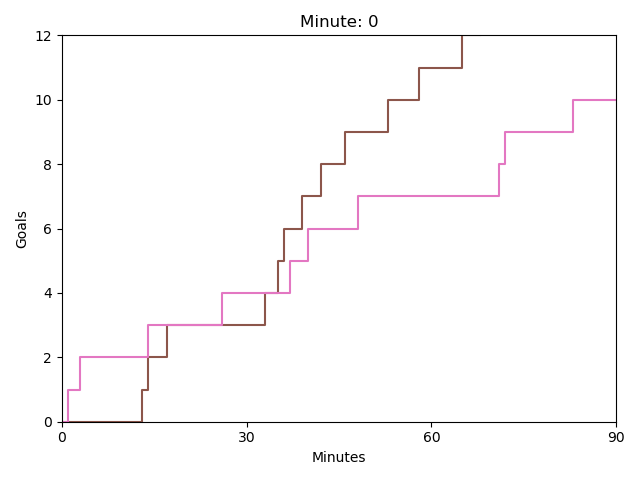

In [21]:
simulate_and_plot_goal_simulation(2, 90)

In [22]:
def simulate_and_animate(simulations, minute, sim_results=None):
    time_range = np.arange(0, minute + 1)

    if sim_results is None:
        print("sim results was none")
        sim_results = simulate_goal(simulations, minute)


    fig, ax = plt.subplots()
    ax.set_xlim(0, minute)
    ax.set_ylim(0, max(arr[-1] for arr in sim_results) + 1)
    ax.set_xlabel("Minute")
    ax.set_ylabel("Goals")

    lines = [ax.plot([], [], alpha=0.6)[0] for _ in range(simulations)]

    def update(frame):
        ax.set_title(f"Minute: {frame}")
        for i, line in enumerate(lines):
            line.set_data(time_range[:frame+1], sim_results[i][:frame+1])
        return lines

    anim = FuncAnimation(
        fig,
        update,
        frames=len(time_range),
        interval=50,   # her frame arası kaç ms beklesin
        blit=True,
        repeat=False,
    )

    plt.show()
    return anim



sim results was none


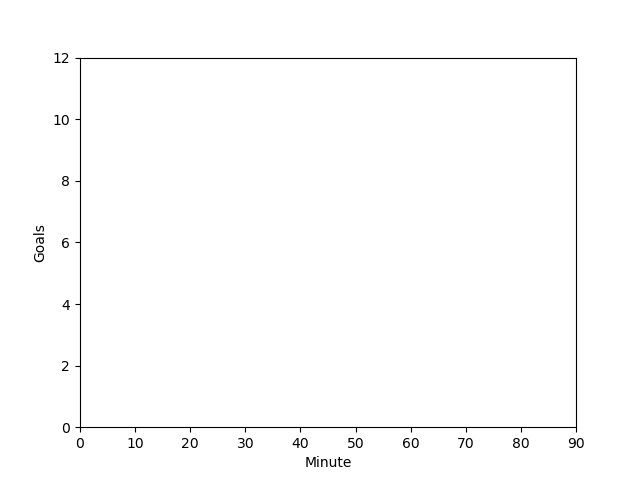

In [23]:
simulate_and_animate(1, 90)

In [24]:
def simulate_and_animate_slider(simulations, minute, sim_results=None):
    time_range = np.arange(0, minute + 1)

    if sim_results is None:
        print("sim results was none")
        sim_results = simulate_goal(simulations, minute)

    fig, ax = plt.subplots()
    ax.set_xlim(0, minute)
    ax.set_ylim(0, max(arr[-1] for arr in sim_results) + 1)
    ax.set_xlabel("Minute")
    ax.set_ylabel("Goals")

    lines = [ax.plot([], [], alpha=0.6)[0] for _ in range(simulations)]

    def update(frame):
        ax.set_title(f"Minute: {frame}")
        for i, line in enumerate(lines):
            line.set_data(time_range[:frame+1], sim_results[i][:frame+1])
        fig.canvas.draw()

    slider = widgets.IntSlider(min=0, max=minute, step=1, value=0, description="Minute")
    widgets.interact(update, frame=slider)
    plt.show()

sim results was none


interactive(children=(IntSlider(value=0, description='Minute', max=90), Output()), _dom_classes=('widget-inter…

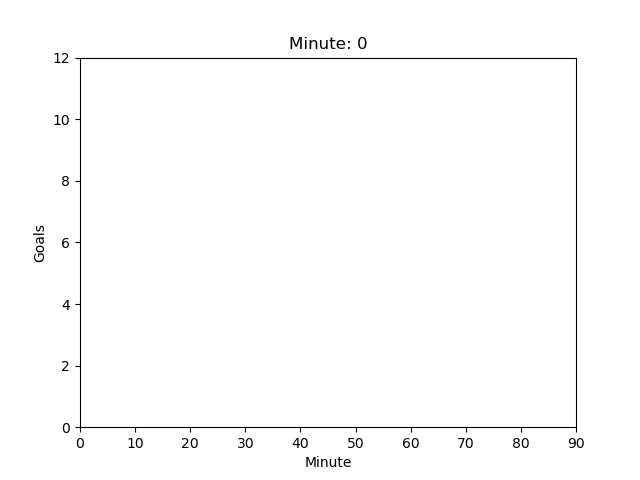

In [25]:
simulate_and_animate_slider(5, 90)


# Simulation of Random Walk


$$S_0 = 0, \qquad S_t = \sum_{i=1}^{t} \xi_i$$

where each step $\xi_i$ is symmetric Bernoulli:

$$\xi_i = \begin{cases} +1 & \text{with probability } \frac{1}{2} \\ -1 & \text{with probability } \frac{1}{2} \end{cases}$$

Properties:

$$\mathbb{E}[S_t] = 0, \qquad \text{Var}(S_t) = t$$





#### Switch from NumPY to jax and how their randomness work:
- seeds determine the first element of random generator, then a function (Mersenne Twister for numpy or Threefry/Philox for JAX) called on that seed.
    - Same seed: always same set of numbers.

- 'rng = np.random.default_rng()' was generating a random seed + STATE(called key in jax).
    - with each call of random generation DIFFERENT number (another iteration in set) is returned.
        - that is enabled by the fact that this key is changing

- key = jax.random.PRNGKey(42)
    - seed = state. state is not updating itself like numpy, thereby can not be set once and then reused.
        - same key  same random number
        - 'key, subkey = jax.random.split(key)' key is changed explicitly.
        - yet, as split is deterministic, just saving the start key/seed is enough for reproductibility


## EXKURS: Jax and Functools Note: Partial

### remembering python decorators:

```
@some_decorator
def my_function():
    ...

is equal to

def my_function():
    ...

my_function = some_decorator(my_function)
```

### functools:
functools is a Python standard library module providing tools for working with functions, mainly for wrapping, combining, or transforming them without rewriting their logic manually.

**functools.partial**
partial takes a function and "freezes" some of its arguments, returning a new function that only needs the remaining ones.
pythonfrom functools import partial

```
def power(base, exponent):
    return base ** exponent

square = partial(power, exponent=2)
square(5)   # 25
square(10)  # 100

#######

@partial(partial, greeting="Hello")
def greet(greeting, name):
    return f"{greeting}, {name}!"

greet("Bora")  # "Hello, Bora!"

````

another example to show capabilities of functool:

```
lru_cache caches return values. If you call the same function with the same arguments again, it skips re-execution and returns the stored result instantly.
pythonfrom functools import lru_cache

@lru_cache(maxsize=None)
def slow_square(x):
    print("computing...")
    return x ** 2

slow_square(5)  # prints "computing...", returns 25
slow_square(5)  # returns 25 instantly, no print
```

### jax.jit internal structure and using with partial:

**What `jax.jit` does:** compiles a function with XLA ( on first call, so later calls run as fast compiled code instead of the Python interpreter.

XLA: open-source machine learning compiler that optimizes mathematical computations and neural network models.

Problem is that, **`jax.jit` recompiles whenever an argument's array *shape* changes.** If `simulations` or `steps` vary between calls, `Z`'s shape changes, forcing a recompile each time.

### tracing logic:

When you call a jit-compiled function, JAX doesn't run your Python code normally. Instead, it runs it once with placeholder objects called tracers instead of real arrays. A tracer only knows shape and dtype, it has no actual value. JAX watches what operations happen to these tracers and builds an XLA computation graph from that. That graph is what actually gets compiled and executed on later calls.

With tracers, `Z = jax.random.normal(key, shape=(simulations, steps))` wouldn't function as JAX needs a real, concrete Python integer for shape. It can't accept "a tracer" there, because a tracer has no value yet, it's just a stand-in.


**What `static_argnames=("simulations", "steps")` does:** tells JAX to treat these two as fixed Python values at compile time, not traced arrays. **JAX only recompiles when their actual values change; same values on a later call reuse the cached compiled version**. Since these two determine `Z`'s shape, JAX needs them marked static.

> Call with simulations=1000, steps=252 → JAX traces and compiles a version specialized for that shape, caches it. <br>
Call again with the same (1000, 252) → cache hit, reuses the compiled version instantly <br>
Call with simulations=5000, steps=252 → different static value → cache miss → traces and compiles a new specialized version.



**Why `partial` is needed:** `jax.jit` normally takes two arguments, `(func, static_argnames=...)`, but decorator syntax (`@decorator`) only expects a single-argument callable. `partial(jax.jit, static_argnames=(...))` pre-fills the second argument, producing a one-argument decorator. So `@partial(jax.jit, static_argnames=(...))` ends up calling `jax.jit(simulate_gbm_paths, static_argnames=(...))` under the hood.

In [26]:
key = jax.random.PRNGKey(42)
key

Array([ 0, 42], dtype=uint32)

In [27]:
jax.random.normal(key)

Array(-0.02830462, dtype=float32)

In [28]:
jax.random.normal(key)

Array(-0.02830462, dtype=float32)

In [50]:

key = jax.random.PRNGKey(int.from_bytes(os.urandom(4), 'big'))
print("jax key = " + str(key))

@partial(jax.jit, static_argnames=("simulations", "minute"))
def simulate_random_walk(key, simulations, minute):
    keys = jax.random.split(key, simulations)

    def single_walk(k):
        steps = jax.random.choice(k, jnp.array([-1, 1]), shape=(minute,))
        cumulative = jnp.cumsum(steps)
        return jnp.concatenate([jnp.array([0]), cumulative])

    return jax.vmap(single_walk)(keys)  # shape: (simulations, minute+1)

results = simulate_random_walk(key, simulations=100, minute=90)
results

jax key = [       0 49950415]


Array([[  0,  -1,  -2, ...,   8,   7,   6],
       [  0,  -1,   0, ...,  -2,  -3,  -4],
       [  0,  -1,   0, ...,  -6,  -7,  -8],
       ...,
       [  0,   1,   0, ...,   0,  -1,   0],
       [  0,  -1,  -2, ..., -14, -13, -14],
       [  0,   1,   2, ...,  26,  27,  26]], dtype=int32)

In [52]:
results_np = np.array(results)  # shape: (simulations, minute+1)
time = np.arange(results_np.shape[1])

fig = make_subplots(rows=1, cols=2, subplot_titles=(
    "Simulated Random Walk Paths",
    f"Distribution at minute {results_np.shape[1]-1}"
))

# Left: all paths overlaid
for path in results_np:
    fig.add_trace(
        go.Scatter(x=time, y=path, mode="lines",
                    line=dict(color="steelblue", width=1),
                    opacity=0.30, showlegend=False),
        row=1, col=1
    )

# Right: distribution of final positions
fig.add_trace(
    go.Histogram(x=results_np[:, -1], nbinsx=20,
                 marker=dict(color="steelblue", line=dict(color="black", width=1)),
                 showlegend=False),
    row=1, col=2
)

fig.update_xaxes(title_text="Minute", row=1, col=1)
fig.update_yaxes(title_text="Cumulative position", row=1, col=1)
fig.update_xaxes(title_text="Final position", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=2)

fig.update_layout(height=500, width=1100, title_text="Random Walk Simulation")
fig.show()

# Brownian Motion

A **standard Brownian motion** (also called a Wiener process) is a stochastic process $W(t) $ satisfying four properties:

**1. Starts at zero**

$$W(0) = 0$$

**2. Continuous paths**

$W(t)$ is a continuous function of $t$ .


**3. Independent increments**

For any $0 \leq u < s < t$, the increment $W(t) - W(s)$ is independent of the past, i.e. independent of $W(u)$ for all $u \leq s$. The process has no memory of how it got to its current value.
- increments are normally distrubited with mean of zero and variance of distance of increment $ \sim \mathcal{N}(0, s - u) $
- independent of what happened before ( $z(s) - z(u)$ is independentend before u)

(Remembering ARCH/GARCH where there was conditional/autorcorrelate relationship between two)

**4. Normally distributed increments**

$$W(s) - W(u) \sim \mathcal{N}(0, \, s - u), \quad \text{for } 0 \leq u < s$$

**The variance of an increment equals the length of the time interval.*** This is the key scaling property: standard deviation scales with $\sqrt{s-u}$, not with $s-u$.

#### POSSIBLE  MISS WHILE REREADING NOTES: (distrubutions) VARIANCE OF DIFFERENCE /INCREMENT IT S-U, THE TIME DIFFERENCE OF THE VALUES WE GET DIFFERENCE OF

## Discretization for simulation

Since increments over disjoint intervals are independent Gaussians, discretizing on a grid $0 = t_0 < t_1 < \dots < t_n$ with step $\Delta t = t_i - t_{i-1}$ gives:

$$W(t_i) = W(t_{i-1}) + Z_i \sqrt{\Delta t}, \quad Z_i \sim \mathcal{N}(0,1) \text{ i.i.d.}$$

(second reminder:, the scalization with $\sqrt{\Delta t}$ is because variance of increment is the S-U = t)

1. draw standard normals,
2. scale with $\sqrt{\Delta t}$
3. cumulativly sum

In [30]:
def brownian_motion_generator_loop(T, dt):
    """
    T: total time horizon (e.g. 10)
    dt: increment size / step size (e.g. 0.1)
    """
    w = 0
    t = 0
    values = {0: 0}  # W(0) = 0

    while t < T:
        shock = norm.rvs() * np.sqrt(dt)
        w = w + shock
        t = t + dt
        values[t] = w

    return values, w #w = last value of brownian motion from iteration

It also can be implemented without loop, as we can recieve from scipy multiple normal random variables:

In [31]:
def brownian_motion_generator_matrix(T, dt):
    """
    T: total time horizon (e.g. 10)
    dt: increment size / step size (e.g. 0.1)
    """


    number_of_shocks = int(T/dt)

    shocks = norm.rvs(size=int(number_of_shocks)) #shock = single random event
    shocks = shocks * np.sqrt(dt)

    values = np.concatenate([[0], np.cumsum(shocks)])

    return values,values[-1]

## Adapting it Monte Carlo Simulation
A single path is one realization of randomness. Monte Carlo was generating many realizations at once and looking at the distribution of outcomes.

1. Using the matrix version
Instead of drawing one shock per iteration in a while loop, drawing all shocks for all paths at once. So we will draw number of shocks * how many paths we wanna create
2. Scaling with delta t
3. Cumulative time along

In [32]:
def brownian_motion_generator_multiple_path(T, dt,n_paths):
    """
    T: total time horizon (e.g. 10)
    dt: increment size / step size (e.g. 0.1)
    n_paths: number of paths to generate
    """

    n_steps = int(T / dt)
    shocks = norm.rvs(size=(n_paths, n_steps)) * np.sqrt(dt)
    paths = np.cumsum(shocks, axis=1)


    zeros_col = np.zeros((n_paths, 1))
    paths = np.hstack([zeros_col, paths])

    return paths

In [33]:

T = 10
dt = 0.01
n_paths = 20

paths = brownian_motion_generator_multiple_path(T, dt, n_paths)
t_grid = np.linspace(0, T, paths.shape[1])



fig = go.Figure()

for i in range(n_paths):
    fig.add_trace(go.Scatter(
        x=t_grid,
        y=paths[i, :],
        mode='lines',
        line=dict(width=1),
        opacity=0.6,
        showlegend=False
    ))

fig.update_layout(
    title=f"{n_paths} Brownian Motion Paths (T={T}, dt={dt})",
    xaxis_title="t",
    yaxis_title="W(t)",
    template="plotly_white"
)

fig.show()

# Risk Neutral Pricing
some quotes:

https://fermatslastspreadsheet.com/2012/01/24/what-is-the-risk-neutral-measure/
https://empslocal.ex.ac.uk/people/staff/NPByott/teaching/FinMaths/2005/risk_neutral.pdf

* Suppose you want to price a derivative, a financial contract whose value depends on some underlying asset (say a stock) at a future date. The payoff is known as a function of the future stock price, but the future stock price itself is random.

***naive approach :***
* figure out the probability distribution of the future stock price in the real world, compute the expected payoff, discount it back using some appropriate discount rate that accounts for risk.
    * The problem is that **"appropriate discount rate accounting for risk"** depends on the risk premium investors demand, which is investor-specific, hard to observe, and different for every asset.

Risk-neutral pricing is sidesteps this.

Instead of using the real-world probabilities and a risk-adjusted discount rate, you can find a different set of probabilities (a different probability measure, called $\mathbb{Q}$  (the risk-neutral measure) such that:

* Under $\mathbb{Q}$ , **every tradeable asset's expected return equals the risk-free rate $r$**  (not its real-world expected return).
* Under Q\mathbb{Q}
Q, you can price any derivative by simply computing the expected payoff and discounting it at the risk-free rate.

$$ \text{Price today} = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\text{payoff at } T]$$

## deriving the formula via one-step binomial model:

* At time $0$, the stock price is $S_0$.
* At time $T$ (one step later), the stock either goes up to $S_0 u$ or down to $S_0 d$, where $u > 1 > d$.
* The risk-free bond grows from $1$ to $e^{rT}$.
    * (remember: $[1 * (1 + r) ] * (1+r)$... converges )
<br>

* We hold a derivative with payoff $C_T$:
    * it takes value $C_u$ in the up state,
    * $C_d$ in the down state
    * (e.g. for a call option, $C_u = \max(S_0u - X, 0)$).

### replication with delta hedge:

We never use the real-world probabilities (how likely the stock actually is to go up or down). Instead we ask: **can we replicate the derivative's exact payoff using a portfolio of stock and risk-free bond?**

Portfolio: $\Delta$ shares of stock + $B$ units of risk-free bond (cash). This portfolio's value at time $T$ must match the derivative's payoff in **BOTH** states:

$$\Delta S_0 u + B e^{rT} = C_u$$
$$\Delta S_0 d + B e^{rT} = C_d$$

$$\Delta = \frac{C_u - C_d}{S_0(u-d)}, \qquad B = e^{-rT}\frac{uC_d - dC_u}{u-d}$$

with =

<small>

- $u$ = **up factor**: if the stock goes up, this is the multiple of $S_0$ it moves to. That is, $S_T = S_0 u$ (in the up state).
- $d$ = **down factor**: if the stock goes down, this is the multiple of $S_0$ it moves to. That is, $S_T = S_0 d$ (in the down state).

</small>

### no arbitrage argument

If this portfolio produces the *exact same* payoff as the derivative in every state (state =  being up or down,C_u/C_d), then to avoid arbitrage their prices today must also be equal (otherwise you could buy the cheap one and sell the expensive one for a risk-free profit). So:

$$C_0 = \Delta S_0 + B$$

Substituting the two unknowns and simplifying:

$$C_0 = e^{-rT}\left[\frac{e^{rT}-d}{u-d} C_u + \frac{u-e^{rT}}{u-d} C_d\right]$$

### Where $p^*$ comes from

To introduce the probability,(behaves like a probability but it is not a one) **WITH THAT THIS OPTION WILL RETURN THE RISK FREE RATE OF r:**,


$$p^* := \frac{e^{rT}-d}{u-d}$$

<small>
with:

- u being up factor, d being down factor, $e^{rT}$ being the risk free return at time t.
- Geometrically, $p^*$ tells you: "where does $e^{rT}$ sit between $d$ and $u$, as a ratio?" (the closer it is to $d$, the smaller $p^*$ is; the closer it is to $u$, the larger $p^*$ is).
-
</small>

With this definition, the formula becomes:

$$C_0 = e^{-rT}\left[p^* C_u + (1-p^*) C_d\right] = e^{-rT}\,\mathbb{E}^{p^*}[C_T]$$

* **this is also what we have deined as Q, the fake possibility.** $p^ = Q$":
$$ \text{Price today} = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\text{payoff at } T]$$




# Black Scholes Equation

$$
\underbrace{\frac{\partial C}{\partial t}}_{\text{Theta}}
+
\frac{1}{2}\sigma^2 S^2
\underbrace{\frac{\partial^2 C}{\partial S^2}}_{\text{Gamma}}
+
rS \underbrace{\frac{\partial C}{\partial S}}_{\text{Delta}}
- rC = 0
$$

* $C = C(S, t)$ : option price — a function of stock price $S$ and time $t$
* $S = S(t)$ : stock price at time $t$
* $\sigma$ : standard deviation of log returns
* $r$ : risk-free interest rate
* $\frac{\partial C}{\partial t}$ : rate of change of option price with respect to time (Theta)
* $\frac{\partial C}{\partial S}$ : rate of change of option price with respect to stock price (Delta)
* $\frac{\partial^2 C}{\partial S^2}$ : rate of change of Delta with respect to stock price (Gamma)

# Closed Form Black Scholes Formula

* after solving with ITO's lemma

* $S_0$ : (current) stock price
* $C_0$ : (current) call option price
* $X$ : Exercise/Strike Price (price at we have right to buy)
* $T$ : time to expiration
* $r$ : risk free interest rate
* $ \sigma$ : standart deviation of LOG RETURNS




$$C_0 = S_0 N(d_1) - X e^{-rT} N(d_2)$$

$$d_1 = \frac{\ln\left(\frac{S_0}{X}\right) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}$$

$$d_2 = \frac{\ln\left(\frac{S_0}{X}\right) + \left(r - \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}$$




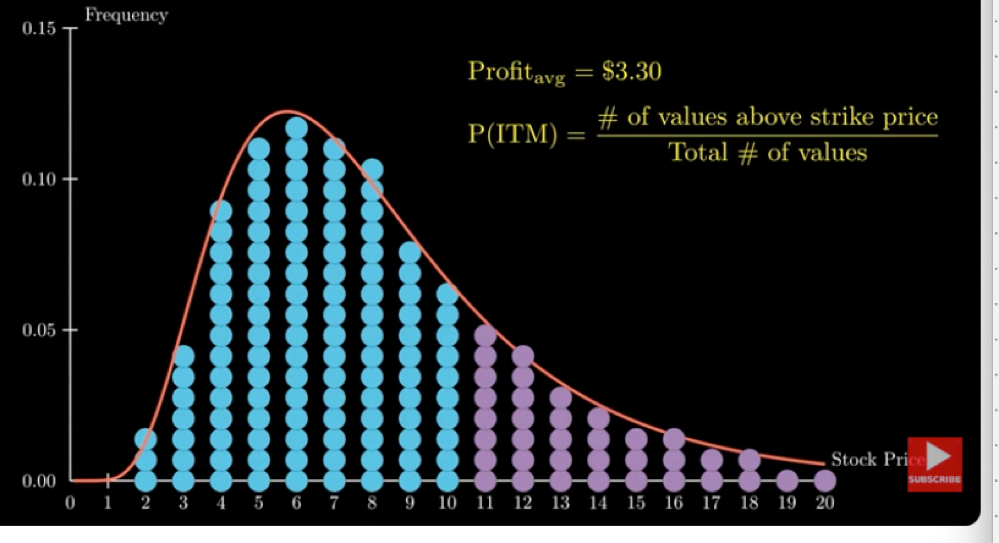

* goal: finding call options fair price at the moment t = 0, $c_0$

* $$
C_0 = \underbrace{S_0 N(d_1)}_{\text{expected gain }} - \underbrace{X e^{-rT} N(d_2)}_{\text{expected cost (present value)}}
$$


* $$
d_1 = \frac{\underbrace{\ln\left(\frac{S_0}{X}\right)}_{\text{distance to strike}} + \underbrace{\left(r + \frac{\sigma^2}{2}\right)T}_{\text{drift + convexity adjustment}}}{\underbrace{\sigma\sqrt{T}}_{\text{normalizer}}}
$$

* $$
d_2 = \underbrace{d_1 - \sigma\sqrt{T}}_{\text{d}_1 \text{ without convexity adjustment}}
$$

* $d2$ = how many standard deviations away the stock's expected (risk-neutral) log-return is from the breakeven point.

* why log return = We assume stock prices are lognormally distrubited.
* log return = just return (profit or loss) expressed in logatimic term.
    * normaly, our return would be (WHEN THE OPTION IS EXCERSISED) $return at t=0 = S_0 - X$
    * in log format: $\ln S_0 - \ln X = \ln\left(\frac{S_0}{X}\right)$
    * rT = drift adjustment, as there is no arbitrage the value should grow every year.
    * $\sigma^2/2$ convexity adjustment, as lognormal distrubitions mean is not $\mu$ but $\mu - \sigma^2/2$
    * $\sigma\sqrt{T}$ standart deviation of lognormal distrubution.
        * as we are willing to calculate the possibility of expected value happening

* $N(d2)$ =  probability that the option expires in-the-money — i.e., S_T > X under the risk-neutral measure.


* N(d1) = IIf the stock price increases by $1, how much does the option price increase?


#### d1 vs d2
* N(d2) asks: will the stock cross the strike? → each scenario counts equally
    * doesnt matter how much higher stock expires
* N(d1) asks: will the stock cross the strike, and how far? → scenarios where $S_T$ is very high get more weight, because **you're receiving the stock itself, not just a binary $1 payout**

#### C_0s value at expiration and present value

$$C_t^{\text{expiration}} = \underbrace{S_t e^{rt} N(d_1)}_{\text{average profit at expiration}} - \underbrace{XN(d_2)}_{\text{average price paid at expiration}}$$

* taking NPV with continious compounding:
$$C_0 = e^{-rt} \cdot C_t^{\text{expiration}} = e^{-rt} \left[ \underbrace{S_t e^{rt} N(d_1)}_{\text{average profit at expiration}} - \underbrace{XN(d_2)}_{\text{average price paid at expiration}} \right]$$

$$ \boxed{C_0 = S_t N(d_1) - Xe^{-rt} N(d_2)} $$







#### Assumptions

- Stock prices are lognormally distributed (log returns are normal)
- Volatility σ is constant over the option's life
- Risk-free rate r is constant
- No dividends paid during the option's life
- European option — exercise only at expiry
- No transaction costs or taxes
- No arbitrage opportunities exist
- Continuous trading is possible

## The Greeks

### Delta ($\Delta$)
Sensitivity of the option price to changes in the underlying asset’s price.

- Definition: $\Delta = \dfrac{\partial V}{\partial S}$, sensitivity of option price to changes in the underlying price
- Interpretation: **hedge ratio, i.e. units of underlying needed to delta-hedge the option**
    - How much of the asset we should buy to

- Range: call options $0 \leq \Delta \leq 1$, put options $-1 \leq \Delta \leq 0$
- At-the-money (ATM) options have $\Delta \approx 0.5$
- Deep in-the-money (ITM) options approach $\Delta \to 1$ (calls) or $\Delta \to -1$ (puts)
- Deep out-of-the-money (OTM) options approach $\Delta \to 0$

### Theta ($\Theta$)
Sensitivity to the passage of time (time decay).

- Definition: $\Theta = \dfrac{\partial V}{\partial t}$, sensitivity to the passage of time
- Usually negative for long option positions: time decay erodes the option's time value
- Decay is non-linear, accelerating as expiration approaches, especially for ATM options
- Long option positions lose value from theta; short positions gain from it
- Relationship: theta and gamma often move in opposite directions in a hedged portfolio (the "theta-gamma tradeoff")

### Vega ($\nu$)
Sensitivity to implied volatility.

- Definition: $\nu = \dfrac{\partial V}{\partial \sigma}$, sensitivity to implied volatility
- **Positive for both calls and puts: higher volatility increases the value of optionality**
    - INCREASED VOLATILITY, INCREASES THE TAILS OF OPTIONS EXPECTED RETURNS AND IT MAKES THE HOLDER BETER OFF
- Highest for ATM options, decreases for deep ITM/OTM options
- Particularly important in stochastic volatility models (e.g. Heston) where $\sigma$ itself is not constant


## #Rho ($\rho$)
Sensitivity to the interest rate.

- Definition: $\rho = \dfrac{\partial V}{\partial r}$, sensitivity to the risk-free interest rate
- Positive for call options, negative for put options
- Generally smaller in magnitude for short-dated options
- Becomes more significant for long-dated options (e.g. LEAPS) or in high-rate environments

### Gamma ($\Gamma$)
(Second order) Sensitivity of delta to changes in the underlying price.

- Definition: $\Gamma = \dfrac{\partial^2 V}{\partial S^2} = \dfrac{\partial \Delta}{\partial S}$, second-order sensitivity of price to the underlying
- Measures how fast delta changes as the underlying moves
- Highest for ATM options, lower for deep ITM/OTM options
- High gamma implies frequent delta-hedge rebalancing, a key concern for market makers
- Basis for gamma scalping strategies


In [34]:
@jax.jit
def black_scholes_call(S0, X, T, r, sigma):
    """
    European Call Option Price via Black-Scholes (JAX).

    Args:
        S0    : Current stock price
        X     : Strike price
        T     : Time to expiration (in years)
        r     : Risk-free interest rate
        sigma : Volatility (std dev of log returns)

    Returns:
        C0    : Call option price
    """

    d1 = (jnp.log(S0 / X) + (r + 0.5 * sigma**2) * T) / (sigma * jnp.sqrt(T))
    d2 = d1 - sigma * jnp.sqrt(T)

    C0 = S0 * ndtr(d1) - X * jnp.exp(-r * T) * ndtr(d2)
    return C0

In [35]:
price = black_scholes_call(S0=100.0, X=105.0, T=1.0, r=0.05, sigma=0.2)

In [36]:
price

Array(8.021353, dtype=float32)

Calculating prices for different strikes at once with JAX vectorisation


In [37]:
strikes = jnp.array([90., 95., 100., 105., 110.])

In [38]:
prices = black_scholes_call(S0=100.0, X=strikes, T=1.0, r=0.05, sigma=0.2)

In [39]:
prices

Array([16.699444, 13.346466, 10.450576,  8.021353,  6.040089], dtype=float32)

# Monte Carlo Pricing via Simulated Brownian Motion

Instead of solving the Black-Scholes PDE in closed form, we can **simulate** the underlying stock price under the risk-neutral measure and estimate the option price as a discounted expected payoff. This connects directly back to the "Brownian Motion" section above.

### From Brownian motion to the stock price (GBM)

Under the risk-neutral measure $\mathbb{Q}$, the stock price follows Geometric Brownian Motion:

$$dS_t = r S_t \, dt + \sigma S_t \, dW_t$$

where $W_t$ is a standard Brownian motion ($W_0 = 0$, independent normal increments $W_t - W_s \sim \mathcal{N}(0, t-s)$, as defined above).

Applying Ito's Lemma (not studied here in detail) $\ln S_t$ gives the closed-form **solution** of this SDE(stochaistic differantiel equation):

$$S_t = S_0 \exp\left( \left(r - \frac{\sigma^2}{2}\right)t + \sigma W_t \right)$$

So simulating the stock price path is really just:
1. Simulate a standard Brownian motion path $W_t$ (cumulative sum of $\mathcal{N}(0, dt)$ increments).
2. Plug it into the exponential formula above.



### Monte Carlo estimator

## For European Call/Put Options

By risk-neutral valuation, the fair call price is the discounted expectation of the terminal payoff:

 **T: time to expiration, not small current "t"**

$$C_0 = e^{-rT}\, \mathbb{E}^{\mathbb{Q}}\big[\max(S_T - X, 0)\big] \approx e^{-rT} \cdot \frac{1}{N}\sum_{i=1}^{N} \max\!\big(S_T^{(i)} - X,\, 0\big)$$

Because $W_t$ has **INDEPENDENT** increments,  $W_T \sim \mathcal{N}(0, T)$ and because we only need **FINAL** value reached ($S_T$)  we don't need to walk through every intermediate time step to get $S_T$, only to *visualize* a full path.

* IMPORTANT: Explained differently, drawing only from a normal distrubution $W_T \sim \mathcal{N}(0, T)$ **ONLY ONCE** per path would be enough.

#### why:

* St's disrubution, distrubution of stocks value at point T can be calculated, its sum of small delta ts, which ends up being T itself
    * $$ W_T \sim \mathcal{N}\left(0, \sum_{i=1}^{M} \Delta t\right) = \mathcal{N}(0, M \cdot \Delta t) = \mathcal{N}(0, T)$$

## When full path simulation is actually needed

- **Path-dependent payoffs**: e.g. Asian options (payoff depends on the *average* $S_t$ over the whole path), lookback options (depends on the running max/min of $S_t$), barrier options (depends on whether $S_t$ ever crosses some level during $[0,T]$). Here you cannot skip to $S_T$, the payoff itself is a function of the entire trajectory.
- **American-style / early exercise options**: need the price at every intermediate step to check if early exercise is optimal


In [40]:
from functools import partial

@partial(jax.jit, static_argnames=("simulations", "steps"))
def simulate_gbm_paths(key, simulations, steps, T, S0, r, sigma):
    """
    Simulate stock price paths by discretizing a standard Brownian motion
    and mapping it through the closed-form GBM solution.

    Args:
        key         : JAX PRNG key
        simulations : number of independent paths (static)
        steps       : number of time steps per path (static)
        [NOTE WE HAVE TAKEN STEP SIZE IN OUR FIRST IMPLEMENTATION, SMALL CHANGE OF LOGIC)
        T           : time to expiration (years)
        S0, r, sigma: Black-Scholes parameters (Current stock price,Risk-free interest rate, Volatility (std dev of log returns)

    Returns:
        t_grid : (steps+1,) time grid, t_grid[0] = 0
        S      : (simulations, steps+1) simulated stock price paths, S[:, 0] = S0
    """
    dt = T / steps
    t_grid = jnp.linspace(0.0, T, steps + 1)

    # Brownian increments
    Z = jax.random.normal(key, shape=(simulations, steps))
    dW = jnp.sqrt(dt) * Z

    # adding zeros to w0
    W = jnp.concatenate([jnp.zeros((simulations, 1)), jnp.cumsum(dW, axis=1)], axis=1)

    # GBM stock price path from the closed-form SDE solution
    S = S0 * jnp.exp((r - 0.5 * sigma**2) * t_grid + sigma * W)

    return t_grid, S

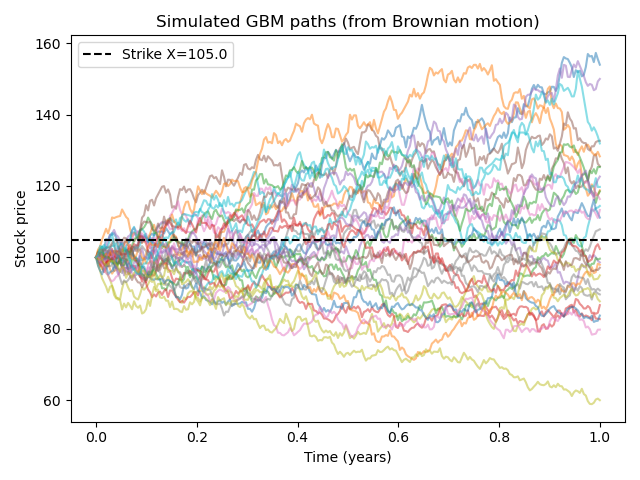

In [41]:
key = jax.random.PRNGKey(int.from_bytes(os.urandom(4), 'big'))

S0, X, T, r, sigma = 100.0, 105.0, 1.0, 0.05, 0.2
t_grid, sample_paths = simulate_gbm_paths(key, simulations=30, steps=252, T=T, S0=S0, r=r, sigma=sigma)

plt.figure()
for path in sample_paths:
    plt.plot(t_grid, path, alpha=0.5)
plt.axhline(X, color='black', linestyle='--', label=f'Strike X={X}')
plt.xlabel('Time (years)')
plt.ylabel('Stock price')
plt.title('Simulated GBM paths (from Brownian motion)')
plt.legend()
plt.tight_layout()
plt.show()

### Pricing: only $S_T$ matters

A European call only pays off at $T$, so for *pricing* we don't need the full path — a single step (`steps=1`) from $0$ to $T$ gives an exact sample of $S_T$, and is far cheaper than simulating hundreds of intermediate steps.





# Monte Carlo with Confidence Interval

We also track the **standard error** of the Monte Carlo estimate, since it's a random estimator and not exact like the closed-form formula:

$$\text{SE} = \frac{\text{std}(\text{discounted payoffS/each estimation})}{\sqrt{N}}, \qquad \text{95\% CI} = \hat{C}_0 \pm 1.96 \cdot \text{SE}$$



### Why we need this

$\hat{C}_0$ (the Monte Carlo price estimate) is an average of $N$ simulated discounted payoffs. Because the payoffs are random, $\hat{C}_0$ itself is random: rerun the simulation and you get a slightly different number. Unlike Black-Scholes, which gives one exact price, Monte Carlo only gives you an *estimate*, so we need a way to quantify how much to trust it.

### Standard error (SE): how spread out is the estimate itself

$$\text{SE} = \frac{\text{std}(\text{discounted payoffs})}{\sqrt{N}}$$

This is not the standard deviation of individual payoffs, it's the standard deviation of **THE AVERAGE** of $N$ payoffs, **what we return at the end as the result of simulation**

* if you average $N$ i.i.d. random variables, the variance of that average shrinks by a factor of $N$,
    * so the standard deviation shrinks by $\sqrt{N}$).
        * Larger $N$ → smaller SE → more precise estimate. This is the $1/\sqrt{N}$ convergence rate that's characteristic of Monte Carlo methods.

### From SE to a confidence interval

By the Central Limit Theorem, when $N$ is large, the distribution of $\hat{C}_0$ (the average of many independent payoffs) is approximately normal, regardless of what the individual payoff distribution looks like. This lets us build an interval around $\hat{C}_0$ that should contain the true price $C_0$ with a stated probability:

$$\text{95\% CI} = \hat{C}_0 \pm 1.96 \cdot \text{SE}$$


### Concrete example

Say the simulation gives $\hat{C}_0 = 10.50$ and $\text{SE} = 0.08$. Then:

$$\text{95\% CI} = [10.50 - 1.96(0.08),\ 10.50 + 1.96(0.08)] = [10.34,\ 10.66]$$

Instead of just reporting "the price is 10.50", you're reporting "the price is very likely between 10.34 and 10.66", which communicates the precision of the estimate, not just its central value.

A narrow CI means a precise estimate; a wide CI means high uncertainty.

In [42]:
@partial(jax.jit, static_argnames=("simulations",))
def black_scholes_call_mc(key, S0, X, T, r, sigma, simulations=200_000):
    """
    Monte Carlo price of a European call: simulate Brownian motion,
    map to S_T via GBM, discount the average payoff.

    Returns:
        price : Monte Carlo estimate of C0
        ci95  : half-width of the 95% confidence interval
    """
    _, S = simulate_gbm_paths(key, simulations, 1, T, S0, r, sigma)
    S_T = S[:, -1]

    discounted_payoffs = jnp.exp(-r * T) * jnp.maximum(S_T - X, 0.0)

    price = jnp.mean(discounted_payoffs)
    ci95 = 1.96 * jnp.std(discounted_payoffs) / jnp.sqrt(simulations)

    return price, ci95

In [43]:
key = jax.random.PRNGKey(int.from_bytes(os.urandom(4), 'big'))

mc_price, ci95 = black_scholes_call_mc(key, S0=S0, X=X, T=T, r=r, sigma=sigma, simulations=500_000)
analytical_price = black_scholes_call(S0=S0, X=X, T=T, r=r, sigma=sigma)

print(f"Monte Carlo price   : {mc_price:.4f}  (95% CI: +/- {ci95:.4f})")
print(f"Analytical BS price : {analytical_price:.4f}")

Monte Carlo price   : 8.0286  (95% CI: +/- 0.0366)
Analytical BS price : 8.0214


### Convergence (Law of Large Numbers)

As $N \to \infty$, the Monte Carlo estimate converges to the true price at a rate of $O(1/\sqrt{N})$. Plotting the running mean of discounted payoffs against the number of simulations shows this convergence directly.

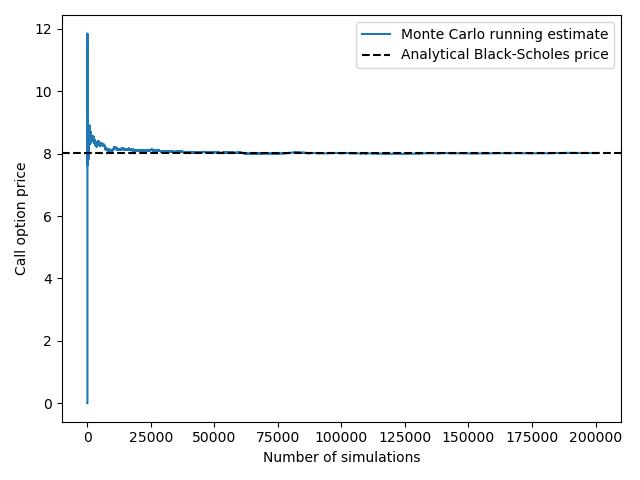

In [44]:
key = jax.random.PRNGKey(int.from_bytes(os.urandom(4), 'big'))

N = 200_000
_, S = simulate_gbm_paths(key, N, 1, T, S0, r, sigma)
discounted_payoff = jnp.exp(-r * T) * jnp.maximum(S[:, -1] - X, 0.0)

running_mean = jnp.cumsum(discounted_payoff) / jnp.arange(1, N + 1)

plt.figure()
plt.plot(running_mean, label='Monte Carlo running estimate')
plt.axhline(float(analytical_price), color='black', linestyle='--', label='Analytical Black-Scholes price')
plt.xlabel('Number of simulations')
plt.ylabel('Call option price')
plt.legend()
plt.tight_layout()
plt.show()